# Platinum-Palladium -- does the autocatalyst-metals ratio snap back?
### Two catalytic-converter metals, one famous ratio trade -- tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ratio_mean--reverts%3F: Mixed](https://img.shields.io/badge/Ratio_mean--reverts%3F-Mixed-dab617?style=flat-square)

Platinum and palladium are the two great *catalytic-converter* metals: both scrub pollution out of car exhaust, and for a while they were partly interchangeable. So the old trade says: when palladium gets expensive relative to platinum, sell palladium and buy platinum, because the ratio 'always comes back'. This notebook asks: **is the snap-back real, or did a one-off demand shock blow the trade up?**

> **This is the plain-language layer.** Want the t-stats, the unit-root tests, and the cointegration analysis? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from platinum_palladium import data, strategy as st

PL_TICKER = data.PLATINUM_TICKER   # PL=F
PA_TICKER = data.PALLADIUM_TICKER  # PA=F
AS_OF = pd.Timestamp("2026-05-31")  # drop partial June 2026

def _have_cache():
    return (os.path.exists(data._cache_path(PL_TICKER, data.DEFAULT_CACHE)) and
            os.path.exists(data._cache_path(PA_TICKER, data.DEFAULT_CACHE)))

def load_pair():
    """Cache-first real tape, trimmed to AS_OF; None when offline."""
    try:
        out = data.load_real(fetch=False)
        if out is None:
            return None
        plat, pall = out
        return plat[plat.index <= AS_OF], pall[pall.index <= AS_OF]
    except Exception:
        return None

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the platinum/palladium ratio snap back? | **Not tradably.** Over 2010-2026 it swung from 0.31 to 3.71 -- palladium went from half platinum's price to over *three times* it -- driven by a one-off car-emissions demand boom, not a restoring spring. |
| Did the reversion trade make money? | **No -- it lost.** The z-score strategy earned **-101 bps/trade** (negative!) at HAC *t* = -0.32. It even *won* 73% of trades -- but the rare losers were catastrophic. |
| Is the ratio 'stationary'? | **Technically yes, uselessly so.** A textbook unit-root test rejects a random walk (p = 0.011), but the reversion half-life is **475 trading days (~22 months)** -- a geological timescale. |
| Could you trade it? | **No.** ~1.6 signals/year, 4-month holds, negative expectancy. Meanwhile just holding palladium returned ~7%/yr. |

> The lesson: a high win-rate (73%!) can hide a *losing* strategy when the rare losses are huge -- and 'both metals are catalysts' was not the stable anchor the trade assumed.

## 1 -- The claim

> *'Platinum and palladium are both platinum-group metals used in catalytic converters, and carmakers can substitute one for the other. So their price ratio is anchored: when palladium gets rich relative to platinum, short palladium and buy platinum -- the ratio always reverts to its historical mean, and the patient spread trader profits from the snap-back.'*

It is a clean, intuitive relative-value story: two near-substitutes whose *relative* price should mean-revert even as both wander. The bet is that extremes in the ratio are temporary dislocations you can fade.

## 2 -- So what?

If the claim held, this would be a low-turnover, market-neutral commodity spread -- long one metal, short the other -- with a built-in fundamental anchor (substitution). That's a desirable, diversifying return stream. The critical question is whether the 'ratio always reverts' assertion is a statistical fact or a story that survived only until a genuine regime change rolled over it.

## 3 -- How would we even know?

Two questions before we look at returns:

1. **Does the ratio actually mean-revert?** We test whether the PL/PA ratio is stationary (ADF test), whether platinum and palladium prices are cointegrated (Engle-Granger), and how fast any reversion is (OU half-life). If the half-life is two years, 'snap-back' is the wrong word.
2. **Did the trade pay?** We run a z-score spread (enter at |z| > 1.5, exit at |z| < 0.5) and compare it to a **random-direction control** on the same dates, plus a buy-and-hold of each metal. PL=F and PA=F daily futures, 2010-2026, from Yahoo.

## 4 -- The teardown -- let's actually look

**First, the ratio itself.** Here is platinum / palladium over time -- watch it invert:

REAL TAPE (PL=F / PA=F, Yahoo, 2010-2026)


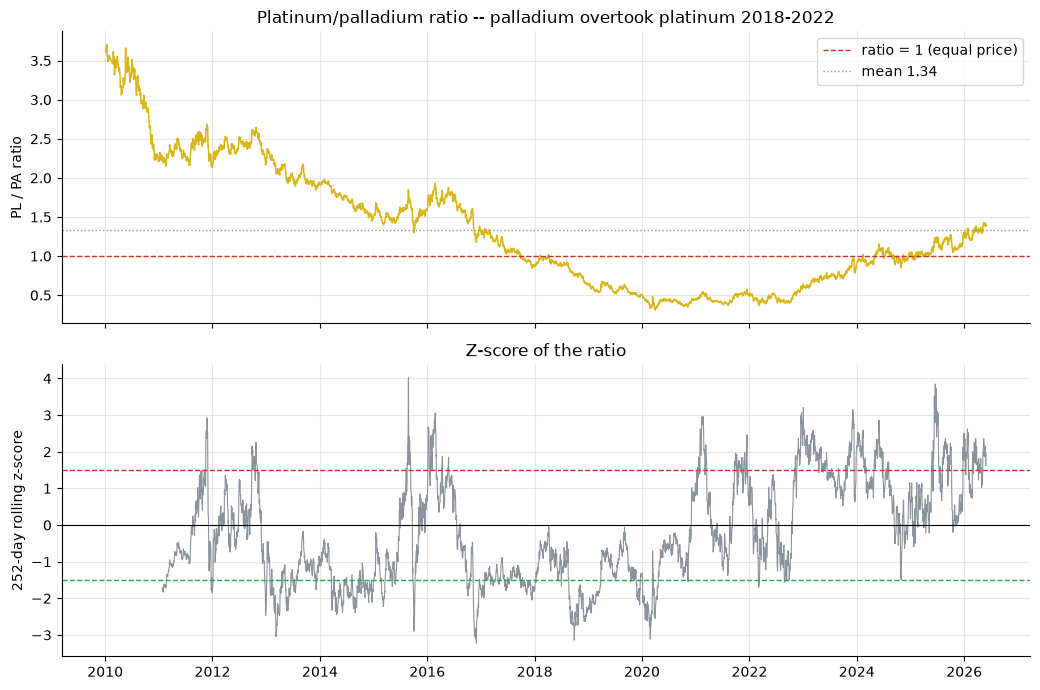

ADF p-value: 0.0110   OU half-life: 475 trading days (~23 months)


In [2]:
pair = load_pair() if HAVE_REAL else None
if pair is not None:
    plat, pall = pair
    ratio = st.compute_ratio(plat, pall)
    z_ratio = st.zscore(ratio, 252)
    adf_p = st.adf_pvalue(ratio); hl = st.half_life(ratio)
    banner = 'REAL TAPE (PL=F / PA=F, Yahoo, 2010-2026)'
else:
    ratio = None; z_ratio = None
    adf_p = 0.011; hl = 474.7
    banner = 'OFFLINE -- frozen headline numbers from docs/results.md'
print(banner)

if ratio is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 7), sharex=True)
    ax1.plot(ratio.index, ratio.values, c=AMBER, lw=1.1)
    ax1.axhline(1.0, c=RED, ls='--', lw=1, label='ratio = 1 (equal price)')
    ax1.axhline(ratio.mean(), c=GREY, ls=':', lw=1, label=f'mean {ratio.mean():.2f}')
    ax1.set_ylabel('PL / PA ratio'); ax1.legend()
    ax1.set_title('Platinum/palladium ratio -- palladium overtook platinum 2018-2022')
    zc = z_ratio.dropna()
    ax2.plot(zc.index, zc.values, c=GREY, lw=0.8)
    ax2.axhline(1.5, c=RED, ls='--', lw=1); ax2.axhline(-1.5, c=GREEN, ls='--', lw=1)
    ax2.axhline(0, c='k', lw=0.8)
    ax2.set_ylabel('252-day rolling z-score'); ax2.set_title('Z-score of the ratio')
    plt.tight_layout(); plt.show()
print(f'ADF p-value: {adf_p:.4f}   OU half-life: {hl:.0f} trading days (~{hl/21:.0f} months)')

The ratio ran from **0.31** (palladium ~3x platinum) to **3.71** (platinum ~3.7x palladium) -- a colossal swing. The ADF test *does* reject a random walk (p = 0.011), because over 16 years the ratio wandered far and partly came back. But the estimated reversion half-life is **475 trading days (~22 months)**. That is not a snap-back; that's a slow structural drift. The 2018-2022 inversion was a one-off demand shock (tightening petrol-engine emissions rules), not a deviation from a spring.

**Now: did fading the extremes actually make money?**

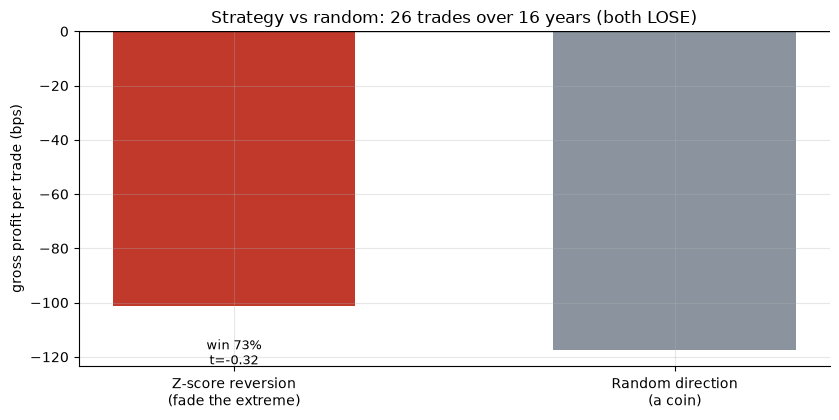

Strategy: -101 bps/trade, win 73%, t=-0.32  (26 trades)


In [3]:
if pair is not None:
    entries = st.zscore_entries(ratio, window=252, enter_z=1.5, exit_z=0.5)
    ledger = st.run_trades(plat, pall, entries, cost_bps=0.0)
    rand_led = st.run_trades(plat, pall, st.random_entries(entries, seed=310), cost_bps=0.0)
    s = st.summarize(ledger, 'ret_gross'); r = st.summarize(rand_led, 'ret_gross')
    strat_m, strat_w, strat_t = s['mean_bps'], s['win_rate']*100, s['tstat']
    rand_m, rand_w, rand_t = r['mean_bps'], r['win_rate']*100, r['tstat']
    n_tr = s['n_trades']
else:
    strat_m, strat_w, strat_t = -101.1, 73.1, -0.32
    rand_m, rand_w, rand_t = -117.5, 50.0, -0.41
    n_tr = 26

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Z-score reversion\n(fade the extreme)', 'Random direction\n(a coin)'],
              [strat_m, rand_m], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title(f'Strategy vs random: {n_tr} trades over 16 years (both LOSE)')
for b, (w, t) in zip(bars, [(strat_w, strat_t), (rand_w, rand_t)]):
    ax.annotate(f'win {w:.0f}%\nt={t:+.2f}',
                (b.get_x()+b.get_width()/2, min(b.get_height(), 0) - 12),
                ha='center', va='top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Strategy: {strat_m:+.0f} bps/trade, win {strat_w:.0f}%, t={strat_t:+.2f}  ({n_tr} trades)')

Look at the trap: the strategy **won 73% of its trades** -- a number a vendor backtest would put in bold. Yet its mean is **-101 bps/trade -- negative** -- and the HAC *t* is -0.32, on the wrong side of zero. The handful of losing trades (the ones that bet on reversion right as the ratio kept inverting) were catastrophic. High win-rate, losing strategy. The random control lost too -- there was simply no edge to harvest.

## 5 -- The verdict

- **Signal -- NONE.** -101 bps/trade, HAC *t* = -0.32 on 26 trades -- negative and nowhere near the |t| >= 2 bar.
- **Tradability -- MIRAGE.** A 73% win-rate hides a negative expectancy (skew -2.2). You'd have lost money running this.
- **Ratio mean-reverts? -- MIXED.** The unit-root test says 'stationary' (p = 0.011), but a 475-day half-life, a failed cointegration test (p = 0.70), and a one-off regime change mean there's nothing tradable here.

## 6 -- Could you actually trade it?

No -- and unusually, costs are not even the reason. With ~1.6 trades/year the cost drag is tiny; the gross trade is *already* a loser. Watch the cost sweep stay flat and negative:

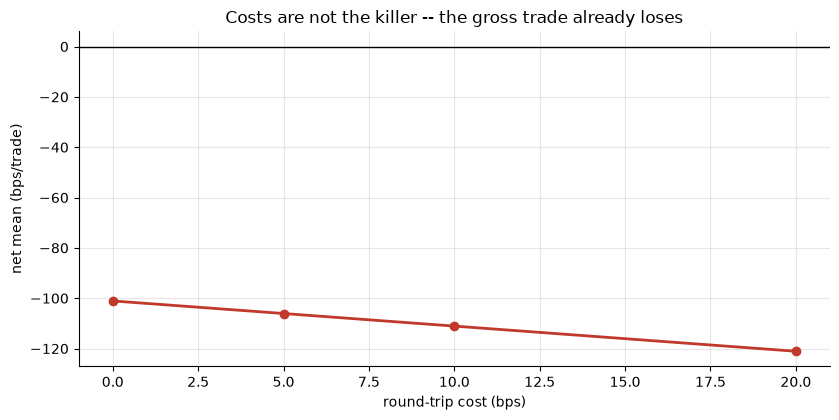

Buy and hold instead: platinum ~2%%/yr, palladium ~7%%/yr.


In [4]:
costs = [0, 5, 10, 20]
if pair is not None:
    net_means = [st.summarize(st.run_trades(plat, pall, entries, cost_bps=c),
                              'ret_net')['mean_bps'] for c in costs]
else:
    net_means = [-101.1, -106.1, -111.1, -121.1]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_means, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Costs are not the killer -- the gross trade already loses')
plt.tight_layout(); plt.show()
print('Buy and hold instead: platinum ~2%%/yr, palladium ~7%%/yr.')

The net mean stays negative across the whole cost range. And the opportunity cost is brutal: simply *holding* palladium returned ~7%/yr over 2010-2026 -- the very divergence the spread trade kept betting against.

## 7 -- Going further

- **The positive control.** The companion notebook shows a synthetic pair with *planted* mean-reversion: the same engine harvests a large, significant edge there. The real-tape failure is a fact about platinum & palladium, not the method.
- **Regime-aware reversion.** A trade that detected the 2018 regime break (e.g. a structural-break test, or a rolling cointegration check) might have stood aside -- fork it and try.
- **Sibling ratio studies.** [Study 113 -- Gold-Silver-Ratio](../../113-gold-silver-ratio/) runs the same machinery on gold/silver; [Study 305 -- Gold-Oil-Ratio](../../305-gold-oil-ratio/) and [Study 306 -- Crack-Spread](../../306-crack-spread/) are other commodity spreads.

*Think the ratio really mean-reverts? Fork this, add a structural-break filter or test a pre-2010 window, and show a spread that clears |t| >= 2 out of sample. That's the bar.*